In [3]:
import re
import random
import pandas as pd
import numpy as np
import csv
from pathlib import Path

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack

import torch
from transformers import BertTokenizer, BertModel

!pip install -q gensim
import gensim.downloader as api
from gensim.models import Word2Vec, FastText

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

In [4]:
rows = []
with open('support-ticket-classification-2000.csv', 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append(row)

df = pd.DataFrame(rows)
y = np.array(df['label'].values)
unique_labels = sorted(list(df['label'].unique()))

print(f"Dataset loaded: {df.shape}")
print(f"Classes: {unique_labels}")
print(f"Class distribution:\n{df['label'].value_counts()}\n")

Dataset loaded: (2000, 4)
Classes: ['account_access', 'billing', 'bug_report', 'refund_request', 'shipping_delivery']
Class distribution:
label
account_access       400
billing              400
refund_request       400
bug_report           400
shipping_delivery    400
Name: count, dtype: int64



In [6]:
def load_stopwords(file_path):
    stopwords = set()
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            word = line.strip().lower()
            if word and not word.startswith('#'):
                stopwords.add(word)
    return stopwords

stopwords = load_stopwords('stopwords.txt')

print(list(stopwords)[:10])

['whom', 'few', 'to', 'off', 'can', 'at', 'yourselves', 'who', 'was', 'from']


In [7]:
def load_exc_files(noun_file, verb_file):
    exc_map = {}
    for file_path in [noun_file, verb_file]:
        if not Path(file_path).exists():
            continue
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 2:
                    inflected = parts[0]
                    lemmas = parts[1:]
                    exc_map[inflected] = lemmas[0]
    return exc_map

exc_map = load_exc_files('dataset/wordnet_noun.exc', 'dataset/wordnet_verb.exc')
for key, value in list(exc_map.items())[:10]:
    print(f"{key}: {value}")

In [8]:
VOWELS = frozenset('aeiou')

MORPH_RULES = {
    # Noun rules: longer/more-specific suffixes FIRST (morphy ordering principle).
    # This ensures ('ses','s') fires for 'buses' before ('s','') would give 'buse'.
    'n': [
        ('ches', 'ch'),
        ('shes', 'sh'),
        ('ses', 's'),
        ('xes', 'x'),
        ('zes', 'z'),
        ('ves', 'f'),
        ('ies', 'y'),
        ('men', 'man'),
        ('s', ''),
    ],
    # Verb rules: longer suffixes first
    'v': [
        ('ies', 'y'),
        ('ing', 'e'),
        ('ing', ''),
        ('ed', 'e'),
        ('ed', ''),
        ('es', 'e'),
        ('es', ''),
        ('s', ''),
    ],
    'a': [('er', ''), ('est', ''), ('er', 'e'), ('est', 'e')],
}

def _is_plausible(candidate):
    """
    Plausibility guard matching WordNet morphy's 'first valid' semantics.
    Without WordNet index files, we approximate validity as:
    length >= 3 AND contains at least one vowel.
    This prevents outputs like 'a' from 'as', 'thi' from 'this'.
    """
    return len(candidate) >= 3 and any(c in VOWELS for c in candidate)

def morph_lemmatize(word, pos='n'):
    """
    Heuristic morphological lemmatizer based on WordNet morphy algorithm
    (Fellbaum 1998, Miller et al. 1990).

    Returns the FIRST suffix-stripped candidate passing the plausibility check.
    This replaces the original min(candidates, key=len) which produced non-words
    (e.g., 'press' -> 'pres', 'as' -> 'a', 'gives' -> 'gif').

    Called with pos='n' from preprocess_text for noun-heavy support ticket domain.
    Verb rules are available in MORPH_RULES['v'] for explicit POS-tagged use.
    Falls back to the original word unchanged if no candidate passes.
    """
    if pos not in MORPH_RULES:
        return word
    for suffix, replacement in MORPH_RULES[pos]:
        if word.endswith(suffix) and len(word) > len(suffix):
            candidate = word[:-len(suffix)] + replacement
            if _is_plausible(candidate):
                return candidate
    return word

In [16]:
def load_lemma_dict(file_path):
    """
    Parse lemma.en.txt (Lin Wei / BNC 2017, 186,523 tokens, 84,487 lemma groups).

    File format: lemma/freq -> form1,form2,...
    Builds reverse map: {inflected_form -> lemma}.

    The original implementation used line.split() which gave parts[0]='be/4109826'
    and parts[1]='->', producing a map that never matched any real token.

    Only pure alphanumeric forms are stored because preprocess_text strips
    punctuation (apostrophes, hyphens) before lookup, making those entries
    unreachable. This reduces memory use and avoids wasted dict lookups.
    """
    lemma_map = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith(';'):
                continue
            if ' -> ' not in line:
                continue
            lemma_part, _, forms_part = line.partition(' -> ')
            lemma = lemma_part.split('/')[0].strip()
            for form in forms_part.split(','):
                form = form.strip()
                # Exclude non-alphanumeric forms (apostrophes, hyphens, dots)
                # that don't survive preprocess_text's regex normalization.
                if form and re.match(r'^[a-z0-9]+$', form) and form not in lemma_map:
                    lemma_map[form] = lemma
    return lemma_map

lemma_map = load_lemma_dict('lemma.en.txt')
print(f"lemma_map loaded: {len(lemma_map)} entries")

lemma_map loaded: 90502 entries


In [17]:
CONTRACTIONS = {
    "can't": "cannot",
    "won't": "will not",
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "i'm": "i am",
    "you're": "you are",
    "we're": "we are",
    "they're": "they are",
    "it's": "it is",
    "that's": "that is",
    "there's": "there is",
    "i've": "i have",
    "we've": "we have",
    "they've": "they have",
    "shouldn't": "should not",
    "couldn't": "could not",
    "wouldn't": "would not",
    "hasn't": "has not",
    "haven't": "have not",
    "hadn't": "had not",
}

DOMAIN_PHRASE_MAP = {
    "log in": "login",
    "sign in": "login",
    "wireless": "wifi",
    "wifi": "wifi",
    "remote access": "vpn",
    "vpn": "vpn",
    "mfa": "mfa",
    "2fa": "mfa",
}

DOMAIN_TOKEN_MAP = {
    "pls": "please",
    "plz": "please",
    "asap": "urgent",
    "u": "you",
    "ur": "your",
    "pwd": "password",
    "acct": "account",
    "acc": "account",
    "auth": "authentication",
    "db": "database",
    "srv": "server",
    "msg": "message",
    "req": "request",
    "otp": "onetimepassword",
    "2fa": "mfa",
}

NEGATION_TOKENS = {"no", "not", "never", "cannot", "failed", "unable", "without"}
DOMAIN_STOPWORDS = {
    "hi",
    "hello",
    "dear",
    "team",
    "please",
    "kindly",
    "thanks",
    "thank",
    "regards",
    "best",
    "sir",
    "madam",
}

ALLOWED_TOKEN_PUNCT = set(".-/@#+_:\\")

BERT_PREPROCESS_CONFIG = {
    "lowercase": True,
    "tag_entities": False,
}

CLASSICAL_PREPROCESS_CONFIG = {
    "lowercase": True,
    "remove_stopwords": True,
    "stopwords": DOMAIN_STOPWORDS,
    "lemmatize": True,
    "use_morph_fallback": False,
    "tag_entities": True,
}

EMBEDDING_PREPROCESS_CONFIG = {
    "lowercase": False,
    "remove_stopwords": False,
    "stopwords": set(),
    "lemmatize": False,
    "use_morph_fallback": False,
    "tag_entities": False,
}

REPLY_CHAIN_PATTERN = re.compile(r"^\s*on\s+.+\s+wrote:\s*$", flags=re.IGNORECASE)
HEADER_PATTERN = re.compile(r"^\s*(from|sent|to|cc|bcc|date)\s*:", flags=re.IGNORECASE)
SIGNATURE_PATTERN = re.compile(
    r"^\s*(thanks|thank you|regards|best regards|kind regards|sincerely|cheers)[\s,!.-]*$",
    flags=re.IGNORECASE,
)
DISCLAIMER_PATTERN = re.compile(
    r"(this\s+(e-?mail|message).{0,120}(confidential|intended only)|please\s+do\s+not\s+reply|"
    r"automatically\s+generated|auto-?generated)",
    flags=re.IGNORECASE,
)

ENTITY_TAG_PATTERNS = [
    ("IP_ADDR", re.compile(r"\b(?:\d{1,3}\.){3}\d{1,3}\b")),
    ("TICKET_ID", re.compile(r"\b(?:inc|ticket|case|ref|req)[-_:#\s]*\d{3,}\b", flags=re.IGNORECASE)),
    ("ORDER_ID", re.compile(r"\b(?:order|ord)[-_:#\s]*\d{3,}\b", flags=re.IGNORECASE)),
    ("VERSION", re.compile(r"\bv?\d+(?:\.\d+){1,3}\b", flags=re.IGNORECASE)),
    ("ERROR_CODE", re.compile(r"\b(?:0x[a-fA-F0-9]{4,}|(?:error|err|errno|exception)[-_:#\s]*[a-z0-9_-]{2,})\b", flags=re.IGNORECASE)),
    ("LONG_NUM", re.compile(r"\b\d{6,}\b")),
]

TOKEN_PATTERN = re.compile(
    r"(?:https?://\S+|www\.\S+)|"
    r"(?:[A-Za-z]:\\[^\s]+)|"
    r"(?:[\w.+-]+@[\w.-]+\.\w+)|"
    r"(?:\b\w+(?:[._:/\\#@+-]\w+)+\b)|"
    r"(?:\b\w+\b)"
)

def normalize_whitespace(text, keep_newlines=False):
    if keep_newlines:
        text = re.sub(r"[^\S\n]+", " ", text)
        text = re.sub(r"\n{3,}", "\n\n", text)
        return text.strip()
    return re.sub(r"\s+", " ", text).strip()

def expand_contractions(text):
    for contraction, expanded in CONTRACTIONS.items():
        text = re.sub(rf"\b{re.escape(contraction)}\b", expanded, text, flags=re.IGNORECASE)
    return text

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = text.replace("\u200b", " ")
    text = re.sub(r"[\t\f\v]+", " ", text)
    return normalize_whitespace(text, keep_newlines=True)

def remove_boilerplate(text):
    lines = [line.strip() for line in text.split("\n")]
    kept_lines = []

    for idx, line in enumerate(lines):
        if not line:
            continue
        if REPLY_CHAIN_PATTERN.match(line):
            break
        if HEADER_PATTERN.match(line):
            continue
        if DISCLAIMER_PATTERN.search(line):
            continue
        if SIGNATURE_PATTERN.match(line) and idx >= max(2, len(lines) // 3):
            break
        kept_lines.append(line)

    cleaned = "\n".join(kept_lines)
    return normalize_whitespace(cleaned)

def apply_domain_mapping(text, phrase_map=None):
    phrase_map = phrase_map or DOMAIN_PHRASE_MAP
    for source, target in phrase_map.items():
        text = re.sub(rf"\b{re.escape(source)}\b", target, text, flags=re.IGNORECASE)
    return text

def normalize_entities(text, add_tags=True):
    if not add_tags:
        return text

    for tag, pattern in ENTITY_TAG_PATTERNS:
        text = pattern.sub(lambda m: f" {m.group(0)} {tag} ", text)

    return normalize_whitespace(text)

def tokenize(text):
    return TOKEN_PATTERN.findall(text)

def normalize_token(token, lowercase=True):
    token = token.strip("\"'`()[]{}<> ")
    token = token.strip(".,;!?")
    if not token:
        return ""

    if token.isalpha():
        token = re.sub(r"(.)\1{2,}", r"\1\1", token)

    mapped = DOMAIN_TOKEN_MAP.get(token.lower())
    if mapped is not None:
        return mapped

    if lowercase:
        return token.lower()
    return token

def is_identifier_like(token):
    if not token:
        return False
    if token.isupper() and len(token) > 1:
        return True
    if any(ch.isdigit() for ch in token):
        return True
    if any(ch in ALLOWED_TOKEN_PUNCT for ch in token):
        return True
    return False

def should_lemmatize(token, config):
    if not config.get("lemmatize", False):
        return False
    if token in NEGATION_TOKENS:
        return False
    if not token.isalpha() or len(token) < 4:
        return False
    if is_identifier_like(token):
        return False
    if token.endswith(("ing", "ed")):
        return False
    return True

def postprocess_tokens(tokens, config, lemma_map=None, exc_map=None):
    processed_tokens = []
    active_stopwords = set(config.get("stopwords", set()))

    for token in tokens:
        token = normalize_token(token, lowercase=config.get("lowercase", True))
        if len(token) <= 1:
            continue

        if config.get("remove_stopwords", False) and token in active_stopwords and token not in NEGATION_TOKENS:
            continue

        if should_lemmatize(token, config):
            lemma_candidate = None
            if exc_map is not None:
                lemma_candidate = exc_map.get(token)
            if lemma_candidate is None and lemma_map is not None:
                lemma_candidate = lemma_map.get(token)
            if lemma_candidate is None and config.get("use_morph_fallback", False):
                lemma_candidate = morph_lemmatize(token, "n")
            if lemma_candidate:
                token = lemma_candidate

        if config.get("remove_stopwords", False) and token in active_stopwords and token not in NEGATION_TOKENS:
            continue

        processed_tokens.append(token)

    return processed_tokens

def preprocess_for_bert(text):
    text = clean_text(text)
    text = remove_boilerplate(text)
    text = expand_contractions(text)
    text = apply_domain_mapping(text)
    text = normalize_entities(text, add_tags=BERT_PREPROCESS_CONFIG.get("tag_entities", False))
    text = normalize_whitespace(text)

    if BERT_PREPROCESS_CONFIG.get("lowercase", True):
        text = text.lower()

    return text

def preprocess_for_classical(text, lemma_map=None, exc_map=None, config=None):
    effective_config = dict(CLASSICAL_PREPROCESS_CONFIG)
    if config:
        effective_config.update(config)
        if "stopwords" in config and config["stopwords"] is not None:
            effective_config["stopwords"] = set(config["stopwords"])

    text = clean_text(text)
    text = remove_boilerplate(text)
    text = expand_contractions(text)
    text = apply_domain_mapping(text)
    text = normalize_entities(text, add_tags=effective_config.get("tag_entities", True))
    tokens = tokenize(text)
    tokens = postprocess_tokens(tokens, effective_config, lemma_map=lemma_map, exc_map=exc_map)
    return " ".join(tokens)

def preprocess_for_tfidf(text, *compat_args):
    # Legacy call order: (text, stopwords, lemma_map, exc_map)
    lemma_lookup = compat_args[1] if len(compat_args) > 1 else None
    exc_lookup = compat_args[2] if len(compat_args) > 2 else None
    return preprocess_for_classical(text, lemma_map=lemma_lookup, exc_map=exc_lookup)

def preprocess_for_embedding(text):
    return preprocess_for_classical(
        text,
        lemma_map=lemma_map,
        exc_map=exc_map,
        config=EMBEDDING_PREPROCESS_CONFIG,
    )

def preprocess_text(text, *compat_args):
    # Backward-compatible alias used by legacy notebook checks.
    lemma_lookup = compat_args[1] if len(compat_args) > 1 else None
    exc_lookup = compat_args[2] if len(compat_args) > 2 else None
    return preprocess_for_classical(text, lemma_map=lemma_lookup, exc_map=exc_lookup)

In [18]:

# ─── REGRESSION TESTS: Lemmatization fixes ───────────────────────────────────
# Verify that the morphy algorithm fixes work correctly
print("\n" + "="*80)
print("LEMMATIZATION REGRESSION TESTS")
print("="*80)

def _check(token, expected):
    got = exc_map.get(token) or lemma_map.get(token) or morph_lemmatize(token, 'n')
    status = '✓ PASS' if got == expected else '✗ FAIL'
    print(f"{status}  {token:20s} -> {got:20s}  (expected {expected:15s})")
    return got == expected

print("\n=== exc_map priority (highest certainty) ===")
_check('is',   'be')       # exc wins over lemma_map
_check('men',  'man')      # irregular noun

print("\n=== lemma_map dictionary lookup (fixed parser) ===")
_check('running',   'run')
_check('presses',   'press')
_check('categories','category')
_check('responses', 'response')

print("\n=== morph fallback (noun rules, longer-suffix-first) ===")
_check('buses',    'bus')      # ('ses','s') rule
_check('captchas', 'captcha')  # ('s','') rule
_check('tickets',  'ticket')

print("\n=== Old bugs now fixed ===")
_check('as',       'as')       # was 'a' (plausibility guard)
_check('gives',    'give')     # was 'gif' (lemma_map now works)
_check('arrives',  'arrive')   # was 'arrif'
_check('resolves', 'resolve')  # was 'resolf'

print("\n" + "="*80)
print(f"✓ All regression tests completed. lemma_map has {len(lemma_map)} entries.")
print("="*80 + "\n")



LEMMATIZATION REGRESSION TESTS

=== exc_map priority (highest certainty) ===
✓ PASS  is                   -> be                    (expected be             )
✓ PASS  men                  -> man                   (expected man            )

=== lemma_map dictionary lookup (fixed parser) ===
✓ PASS  running              -> run                   (expected run            )
✓ PASS  presses              -> press                 (expected press          )
✓ PASS  categories           -> category              (expected category       )
✓ PASS  responses            -> response              (expected response       )

=== morph fallback (noun rules, longer-suffix-first) ===
✓ PASS  buses                -> bus                   (expected bus            )
✓ PASS  captchas             -> captcha               (expected captcha        )
✓ PASS  tickets              -> ticket                (expected ticket         )

=== Old bugs now fixed ===
✓ PASS  as                   -> as                    (

In [19]:
def compose_ticket_text(subject, text):
    subject = "" if pd.isna(subject) else str(subject).strip()
    text = "" if pd.isna(text) else str(text).strip()
    return f"SUBJECT: {subject} BODY: {text}".strip()

raw_texts = []
bert_texts = []
tfidf_texts = []
embedding_texts = []

for idx in range(len(df)):
    raw = compose_ticket_text(df.iloc[idx]['subject'], df.iloc[idx]['text'])
    raw_texts.append(raw)
    bert_texts.append(preprocess_for_bert(raw))
    tfidf_texts.append(preprocess_for_tfidf(raw, stopwords, lemma_map, exc_map))
    embedding_texts.append(preprocess_for_embedding(raw))

df['raw_text'] = raw_texts
df['bert_text'] = bert_texts
df['tfidf_text'] = tfidf_texts
df['embedding_text'] = embedding_texts

x_train, x_test, y_train, y_test = train_test_split(
    np.arange(len(df)),
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
 )

print(f"Train split: {len(x_train)} samples")
print(f"Test split: {len(x_test)} samples")

sample_idx = x_train[0]
print("\nSample model-wise text views:")
print(f"Raw text        : {df.iloc[sample_idx]['raw_text'][:180]}")
print(f"BERT text       : {df.iloc[sample_idx]['bert_text'][:180]}")
print(f"TF-IDF text     : {df.iloc[sample_idx]['tfidf_text'][:180]}")
print(f"Embedding text  : {df.iloc[sample_idx]['embedding_text'][:180]}\n")

preview_count = min(3, len(x_test))
preview_rows = []
for idx in x_test[:preview_count]:
    preview_rows.append({
        'label': df.iloc[idx]['label'],
        'raw_text': df.iloc[idx]['raw_text'][:110],
        'bert_prep': df.iloc[idx]['bert_text'][:110],
        'tfidf_prep': df.iloc[idx]['tfidf_text'][:110],
        'embed_prep': df.iloc[idx]['embedding_text'][:110],
    })

print("Test-set representation preview (Raw vs Preprocessed views):")
print(pd.DataFrame(preview_rows).to_string(index=False))
print()

Train split: 1500 samples
Test split: 500 samples

Sample model-wise text views:
Raw text        : SUBJECT: Need a corrected receipt BODY: I provided my VAT number during signup but invoices still show full tax charges. Please issue an updated copy. Can you explain the extra cha
BERT text       : subject: need a corrected receipt body: i provided my vat number during signup but invoices still show full tax charges. please issue an updated copy. can you explain the extra cha
TF-IDF text     : subject need corrected receipt body provided my vat numb during signup but invoice still show full tax charge issue an updated copy can you explain the extra charge
Embedding text  : SUBJECT Need corrected receipt BODY provided my VAT number during signup but invoices still show full tax charges Please issue an updated copy Can you explain the extra charge

Test-set representation preview (Raw vs Preprocessed views):
            label                                                                 

In [20]:
def build_tfidf_word_vectorizer(max_features=35000):
    return TfidfVectorizer(
        lowercase=True,
        analyzer='word',
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        strip_accents='unicode',
        max_features=max_features,
    )

def build_tfidf_char_vectorizer(max_features=20000):
    return TfidfVectorizer(
        lowercase=True,
        analyzer='char_wb',
        ngram_range=(3, 5),
        min_df=2,
        sublinear_tf=True,
        max_features=max_features,
    )

def build_tfidf_feature_pair(train_texts, test_texts, word_max=35000, char_max=20000):
    tfidf_word = build_tfidf_word_vectorizer(max_features=word_max)
    tfidf_char = build_tfidf_char_vectorizer(max_features=char_max)

    X_train_word = tfidf_word.fit_transform(train_texts)
    X_test_word = tfidf_word.transform(test_texts)
    X_train_char = tfidf_char.fit_transform(train_texts)
    X_test_char = tfidf_char.transform(test_texts)

    X_train = hstack([X_train_word, X_train_char]).tocsr()
    X_test = hstack([X_test_word, X_test_char]).tocsr()
    return X_train, X_test, len(tfidf_word.vocabulary_), len(tfidf_char.vocabulary_)

train_texts_tfidf_prep = [df.iloc[i]['tfidf_text'] for i in x_train]
test_texts_tfidf_prep = [df.iloc[i]['tfidf_text'] for i in x_test]
train_texts_tfidf_raw = [df.iloc[i]['raw_text'] for i in x_train]
test_texts_tfidf_raw = [df.iloc[i]['raw_text'] for i in x_test]

X_train_tfidf_prep, X_test_tfidf_prep, prep_word_vocab, prep_char_vocab = build_tfidf_feature_pair(
    train_texts_tfidf_prep, test_texts_tfidf_prep, word_max=35000, char_max=20000
 )
X_train_tfidf_raw, X_test_tfidf_raw, raw_word_vocab, raw_char_vocab = build_tfidf_feature_pair(
    train_texts_tfidf_raw, test_texts_tfidf_raw, word_max=40000, char_max=25000
 )

print("TF-IDF representation summary:")
print(
    f"  Preprocessed -> word_vocab={prep_word_vocab}, char_vocab={prep_char_vocab}, "
    f"shape={X_train_tfidf_prep.shape}"
 )
print(
    f"  Raw          -> word_vocab={raw_word_vocab}, char_vocab={raw_char_vocab}, "
    f"shape={X_train_tfidf_raw.shape}\n"
 )

TF-IDF representation summary:
  Preprocessed -> word_vocab=8254, char_vocab=12178, shape=(1500, 20432)
  Raw          -> word_vocab=8553, char_vocab=14505, shape=(1500, 23058)



In [21]:
def scale_dense_features(X_train, X_test):
    scaler = StandardScaler()
    return scaler.fit_transform(X_train), scaler.transform(X_test)

def get_avg_embedding(text, keyed_vectors, vector_size):
    words = text.split()
    vectors = [keyed_vectors[word] for word in words if word in keyed_vectors]
    if not vectors:
        return np.zeros(vector_size, dtype=np.float32)
    return np.mean(vectors, axis=0)

def build_embedding_feature_pair(df, train_idx, test_idx, keyed_vectors, vector_size, prep_col='embedding_text', raw_col='raw_text'):
    X_train_prep = np.array([get_avg_embedding(df.iloc[i][prep_col], keyed_vectors, vector_size) for i in train_idx])
    X_test_prep = np.array([get_avg_embedding(df.iloc[i][prep_col], keyed_vectors, vector_size) for i in test_idx])
    X_train_raw = np.array([get_avg_embedding(df.iloc[i][raw_col], keyed_vectors, vector_size) for i in train_idx])
    X_test_raw = np.array([get_avg_embedding(df.iloc[i][raw_col], keyed_vectors, vector_size) for i in test_idx])

    X_train_prep, X_test_prep = scale_dense_features(X_train_prep, X_test_prep)
    X_train_raw, X_test_raw = scale_dense_features(X_train_raw, X_test_raw)
    return X_train_prep, X_test_prep, X_train_raw, X_test_raw

def train_local_word2vec(sentences, vector_size=300, epochs=45):
    local_model = Word2Vec(
        sentences=sentences,
        vector_size=vector_size,
        window=5,
        min_count=1,
        sg=1,
        workers=4,
        seed=RANDOM_STATE,
        epochs=epochs,
    )
    return local_model.wv

print("Loading pretrained Word2Vec (Google News 300d)...")
train_sentences_embedding = [df.iloc[i]['embedding_text'].split() for i in x_train]
try:
    w2v_vectors = api.load("word2vec-google-news-300")
    w2v_dim = w2v_vectors.vector_size
    print(f"✓ Pretrained Word2Vec loaded: {w2v_dim}-dimensional")
except Exception as ex:
    print(f"⚠ Pretrained Word2Vec unavailable ({ex}). Training local fallback model...")
    w2v_vectors = train_local_word2vec(train_sentences_embedding, vector_size=300, epochs=55)
    w2v_dim = w2v_vectors.vector_size
    print(f"✓ Local Word2Vec trained: {w2v_dim}-dimensional")

print("Creating Word2Vec vectors for preprocessed and raw text...")
X_train_w2v_prep, X_test_w2v_prep, X_train_w2v_raw, X_test_w2v_raw = build_embedding_feature_pair(
    df,
    x_train,
    x_test,
    w2v_vectors,
    w2v_dim,
    prep_col='embedding_text',
    raw_col='raw_text',
)

# Backward-compatibility aliases for downstream cells that may reference legacy names.
X_train_w2v, X_test_w2v = X_train_w2v_prep, X_test_w2v_prep
print(f"✓ Word2Vec (Preprocessed): shape={X_train_w2v_prep.shape}")
print(f"✓ Word2Vec (Raw): shape={X_train_w2v_raw.shape}\n")

Loading pretrained Word2Vec (Google News 300d)...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
✓ Pretrained Word2Vec loaded: 300-dimensional
Creating Word2Vec vectors for preprocessed and raw text...
✓ Word2Vec (Preprocessed): shape=(1500, 300)
✓ Word2Vec (Raw): shape=(1500, 300)



In [22]:
# ==================== FEATURE EXTRACTION: GLOVE ====================

print("Loading GloVe embeddings (100d)...")
try:
    glove_vectors = api.load("glove-wiki-gigaword-100")
    glove_dim = glove_vectors.vector_size
    print(f"✓ GloVe loaded: {glove_dim}-dimensional")
except Exception as ex:
    print(f"⚠ GloVe unavailable ({ex}). Training local fallback vectors...")
    glove_vectors = train_local_word2vec(train_sentences_embedding, vector_size=100, epochs=50)
    glove_dim = glove_vectors.vector_size
    print(f"✓ Local fallback vectors trained: {glove_dim}-dimensional")

print("Creating GloVe vectors for preprocessed and raw text...")
X_train_glove_prep, X_test_glove_prep, X_train_glove_raw, X_test_glove_raw = build_embedding_feature_pair(
    df,
    x_train,
    x_test,
    glove_vectors,
    glove_dim,
    prep_col='embedding_text',
    raw_col='raw_text',
)

# Backward-compatibility aliases for downstream cells that may reference legacy names.
X_train_glove, X_test_glove = X_train_glove_prep, X_test_glove_prep
print(f"✓ GloVe (Preprocessed): shape={X_train_glove_prep.shape}")
print(f"✓ GloVe (Raw): shape={X_train_glove_raw.shape}\n")

Loading GloVe embeddings (100d)...
✓ GloVe loaded: 100-dimensional
Creating GloVe vectors for preprocessed and raw text...
✓ GloVe (Preprocessed): shape=(1500, 100)
✓ GloVe (Raw): shape=(1500, 100)



In [23]:
# ==================== FEATURE EXTRACTION: FASTTEXT ====================

print("Training FastText embeddings (subword-aware)...")

train_sentences_embedding_prep = [df.iloc[i]['embedding_text'].split() for i in x_train]
train_sentences_embedding_raw = [df.iloc[i]['raw_text'].lower().split() for i in x_train]

fasttext_prep = FastText(
    vector_size=220,
    window=5,
    min_count=1,
    sg=1,
    min_n=3,
    max_n=6,
    workers=4,
    seed=RANDOM_STATE,
 )
fasttext_prep.build_vocab(train_sentences_embedding_prep)
fasttext_prep.train(train_sentences_embedding_prep, total_examples=len(train_sentences_embedding_prep), epochs=55)

fasttext_raw = FastText(
    vector_size=220,
    window=5,
    min_count=1,
    sg=1,
    min_n=3,
    max_n=6,
    workers=4,
    seed=RANDOM_STATE,
 )
fasttext_raw.build_vocab(train_sentences_embedding_raw)
fasttext_raw.train(train_sentences_embedding_raw, total_examples=len(train_sentences_embedding_raw), epochs=55)

print("Creating FastText vectors for preprocessed and raw text...")
X_train_fasttext_prep = np.array([
    get_avg_embedding(df.iloc[i]['embedding_text'], fasttext_prep.wv, fasttext_prep.vector_size)
    for i in x_train
 ])
X_test_fasttext_prep = np.array([
    get_avg_embedding(df.iloc[i]['embedding_text'], fasttext_prep.wv, fasttext_prep.vector_size)
    for i in x_test
 ])
X_train_fasttext_prep, X_test_fasttext_prep = scale_dense_features(X_train_fasttext_prep, X_test_fasttext_prep)

X_train_fasttext_raw = np.array([
    get_avg_embedding(df.iloc[i]['raw_text'], fasttext_raw.wv, fasttext_raw.vector_size)
    for i in x_train
 ])
X_test_fasttext_raw = np.array([
    get_avg_embedding(df.iloc[i]['raw_text'], fasttext_raw.wv, fasttext_raw.vector_size)
    for i in x_test
 ])
X_train_fasttext_raw, X_test_fasttext_raw = scale_dense_features(X_train_fasttext_raw, X_test_fasttext_raw)

print(f"✓ FastText (Preprocessed): shape={X_train_fasttext_prep.shape}")
print(f"✓ FastText (Raw): shape={X_train_fasttext_raw.shape}\n")

Training FastText embeddings (subword-aware)...
Creating FastText vectors for preprocessed and raw text...
✓ FastText (Preprocessed): shape=(1500, 220)
✓ FastText (Raw): shape=(1500, 220)



In [24]:
# ==================== FEATURE EXTRACTION: BERT ====================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

tokenizer_bert = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.to(device)
bert_model.eval()

bert_batch_size = 24 if device.type == 'cuda' else 10
bert_max_length = 192
print(f"✓ BERT loaded (output dimension: 768, batch_size={bert_batch_size}, max_length={bert_max_length})")

def extract_bert_features(texts, tokenizer, model, device, batch_size=16, max_length=192):
    """Extract attention-masked mean pooled embeddings from BERT."""
    features = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]

            encodings = tokenizer(
                batch_texts,
                add_special_tokens=True,
                max_length=max_length,
                padding=True,
                truncation=True,
                return_tensors='pt'
            )

            input_ids = encodings['input_ids'].to(device)
            attention_mask = encodings['attention_mask'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            token_embeddings = outputs.last_hidden_state
            mask_expanded = attention_mask.unsqueeze(-1).float()
            sum_embeddings = (token_embeddings * mask_expanded).sum(dim=1)
            sum_mask = mask_expanded.sum(dim=1).clamp(min=1e-9)
            batch_features = (sum_embeddings / sum_mask).cpu().numpy()
            features.extend(batch_features)

    return np.array(features)

print("Extracting BERT features from preprocessed text...")
train_texts_bert_prep = [df.iloc[i]['bert_text'] for i in x_train]
test_texts_bert_prep = [df.iloc[i]['bert_text'] for i in x_test]
X_train_bert_prep = extract_bert_features(
    train_texts_bert_prep, tokenizer_bert, bert_model, device, batch_size=bert_batch_size, max_length=bert_max_length
 )
X_test_bert_prep = extract_bert_features(
    test_texts_bert_prep, tokenizer_bert, bert_model, device, batch_size=bert_batch_size, max_length=bert_max_length
 )
X_train_bert_prep, X_test_bert_prep = scale_dense_features(X_train_bert_prep, X_test_bert_prep)
print(f"✓ BERT (Preprocessed): shape={X_train_bert_prep.shape}")

print("Extracting BERT features from raw text...")
train_texts_bert_raw = [df.iloc[i]['raw_text'] for i in x_train]
test_texts_bert_raw = [df.iloc[i]['raw_text'] for i in x_test]
X_train_bert_raw = extract_bert_features(
    train_texts_bert_raw, tokenizer_bert, bert_model, device, batch_size=bert_batch_size, max_length=bert_max_length
 )
X_test_bert_raw = extract_bert_features(
    test_texts_bert_raw, tokenizer_bert, bert_model, device, batch_size=bert_batch_size, max_length=bert_max_length
 )
X_train_bert_raw, X_test_bert_raw = scale_dense_features(X_train_bert_raw, X_test_bert_raw)
print(f"✓ BERT (Raw): shape={X_train_bert_raw.shape}\n")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ BERT loaded (output dimension: 768, batch_size=24, max_length=192)
Extracting BERT features from preprocessed text...
✓ BERT (Preprocessed): shape=(1500, 768)
Extracting BERT features from raw text...
✓ BERT (Raw): shape=(1500, 768)



In [31]:
# ==================== TRAIN ALL MODELS + STORE PREDICTIONS ====================

features = {}

def add_feature_if_available(feature_name, train_var_name, test_var_name):
    if train_var_name in globals() and test_var_name in globals():
        features[feature_name] = (globals()[train_var_name], globals()[test_var_name])
    else:
        print(f"Skipping {feature_name}: missing {train_var_name} or {test_var_name}")

def add_feature_with_aliases(feature_name, train_var_names, test_var_names):
    train_name = next((name for name in train_var_names if name in globals()), None)
    test_name = next((name for name in test_var_names if name in globals()), None)

    if train_name and test_name:
        features[feature_name] = (globals()[train_name], globals()[test_name])
    else:
        print(f"Skipping {feature_name}: missing any of {train_var_names} or {test_var_names}")

# Register features
add_feature_if_available('TF-IDF (Preprocessed)', 'X_train_tfidf_prep', 'X_test_tfidf_prep')
add_feature_if_available('TF-IDF (Raw)', 'X_train_tfidf_raw', 'X_test_tfidf_raw')
add_feature_with_aliases('Word2Vec (Preprocessed)', ['X_train_w2v_prep', 'X_train_w2v'], ['X_test_w2v_prep', 'X_test_w2v'])
add_feature_if_available('Word2Vec (Raw)', 'X_train_w2v_raw', 'X_test_w2v_raw')
add_feature_with_aliases('GloVe (Preprocessed)', ['X_train_glove_prep', 'X_train_glove'], ['X_test_glove_prep', 'X_test_glove'])
add_feature_if_available('GloVe (Raw)', 'X_train_glove_raw', 'X_test_glove_raw')
add_feature_if_available('FastText (Preprocessed)', 'X_train_fasttext_prep', 'X_test_fasttext_prep')
add_feature_if_available('FastText (Raw)', 'X_train_fasttext_raw', 'X_test_fasttext_raw')
add_feature_if_available('BERT (Preprocessed)', 'X_train_bert_prep', 'X_test_bert_prep')
add_feature_if_available('BERT (Raw)', 'X_train_bert_raw', 'X_test_bert_raw')

print(f"\nRegistered feature sets: {list(features.keys())}\n")

classifier_names = ['SVM', 'Logistic Regression', 'KNN']

def build_classifier(clf_name):
    if clf_name == 'SVM':
        return SVC(kernel='linear', C=2.5, class_weight='balanced', random_state=RANDOM_STATE)
    if clf_name == 'Logistic Regression':
        return LogisticRegression(max_iter=3500, C=3.0, class_weight='balanced', solver='liblinear', random_state=RANDOM_STATE)
    return KNeighborsClassifier(n_neighbors=7, weights='distance', metric='cosine', algorithm='brute', n_jobs=-1)

results = {}
macro_f1_results = {}
predictions_store = {}

print("Training all models...\n")
print(f"{'Feature':<30} {'SVM':<10} {'LogReg':<10} {'KNN':<10}")
print("=" * 65)

for feature_name, (X_train, X_test) in features.items():
    results[feature_name] = {}
    macro_f1_results[feature_name] = {}
    predictions_store[feature_name] = {}

    row_scores = []

    for clf_name in classifier_names:
        model = build_classifier(clf_name)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        macro_f1 = f1_score(y_test, y_pred, average='macro')

        results[feature_name][clf_name] = accuracy
        macro_f1_results[feature_name][clf_name] = macro_f1
        predictions_store[feature_name][clf_name] = y_pred

        row_scores.append(f"{accuracy:.4f}")

    print(f"{feature_name:<30} {row_scores[0]:<10} {row_scores[1]:<10} {row_scores[2]:<10}")

print("\n✓ All models trained!\n")


# ==================== MISCLASSIFICATION ANALYSIS ====================

def get_misclassified(feature_name, clf_name):
    y_pred = predictions_store[feature_name][clf_name]
    misclassified = []

    for i, idx in enumerate(x_test):
        if y_pred[i] != y_test[i]:
            misclassified.append((i, idx, y_test[i], y_pred[i]))

    return misclassified


# Example: Best model
best_feature = 'TF-IDF (Raw)'
best_clf = 'SVM'

misclassified = get_misclassified(best_feature, best_clf)
print(f"\nTotal misclassified by {best_feature} + {best_clf}: {len(misclassified)}\n")


# ==================== PRINT MISCLASSIFIED SAMPLES ====================

print("Sample Misclassified Examples:\n")

for i, idx, true_label, pred_label in misclassified[:10]:
    print("TEXT:", df.iloc[idx]['raw_text'])
    print("TRUE:", true_label)
    print("PRED:", pred_label)
    print("-"*80)


# ==================== CROSS-MODEL COMPARISON ====================

compare_feature = 'BERT (Raw)'
compare_clf = 'SVM'

compare_pred = predictions_store[compare_feature][compare_clf]

print("\nCases where TF-IDF fails but BERT succeeds:\n")

count = 0
for i, idx in enumerate(x_test):
    tfidf_pred = predictions_store[best_feature][best_clf][i]
    bert_pred = compare_pred[i]

    if tfidf_pred != y_test[i] and bert_pred == y_test[i]:
        print("TEXT:", df.iloc[idx]['raw_text'])
        print("TRUE:", y_test[i])
        print("TF-IDF:", tfidf_pred)
        print("BERT:", bert_pred)
        print("="*80)
        count += 1
        if count >= 5:
            break


print("\nCases where BERT fails but TF-IDF succeeds:\n")

count = 0
for i, idx in enumerate(x_test):
    tfidf_pred = predictions_store[best_feature][best_clf][i]
    bert_pred = compare_pred[i]

    if bert_pred != y_test[i] and tfidf_pred == y_test[i]:
        print("TEXT:", df.iloc[idx]['raw_text'])
        print("TRUE:", y_test[i])
        print("TF-IDF:", tfidf_pred)
        print("BERT:", bert_pred)
        print("="*80)
        count += 1
        if count >= 5:
            break


Registered feature sets: ['TF-IDF (Preprocessed)', 'TF-IDF (Raw)', 'Word2Vec (Preprocessed)', 'Word2Vec (Raw)', 'GloVe (Preprocessed)', 'GloVe (Raw)', 'FastText (Preprocessed)', 'FastText (Raw)', 'BERT (Preprocessed)', 'BERT (Raw)']

Training all models...

Feature                        SVM        LogReg     KNN       
TF-IDF (Preprocessed)          0.9540     0.9560     0.9440    
TF-IDF (Raw)                   0.9620     0.9500     0.9420    
Word2Vec (Preprocessed)        0.9160     0.9200     0.9300    
Word2Vec (Raw)                 0.8980     0.9040     0.9140    
GloVe (Preprocessed)           0.8560     0.8480     0.8780    
GloVe (Raw)                    0.8400     0.8420     0.8860    
FastText (Preprocessed)        0.9180     0.9300     0.9320    
FastText (Raw)                 0.9320     0.9240     0.9320    
BERT (Preprocessed)            0.9260     0.9420     0.9120    
BERT (Raw)                     0.9220     0.9420     0.9200    

✓ All models trained!


Total miscla


Word2Vec (Raw) + SVM
Total errors: 51

TEXT: SUBJECT: Shipping insurance added to bill without consent BODY: I see a line item for shipping insurance I never agreed to. Remove it from future orders and explain why it appeared.
TRUE: billing
PRED: shipping_delivery
--------------------------------------------------------------------------------
TEXT: SUBJECT: Negotiation leverage unequal BODY: As a small company I have no negotiation power for better rates.
TRUE: billing
PRED: refund_request
--------------------------------------------------------------------------------
TEXT: SUBJECT: Family plan billing issues BODY: I upgraded to the family plan but I'm still being charged for individual accounts separately instead of one family plan charge.
TRUE: billing
PRED: refund_request
--------------------------------------------------------------------------------

Word2Vec (Raw) fails but TF-IDF (Raw) succeeds
TEXT: SUBJECT: Negotiation leverage unequal BODY: As a small company I have no neg

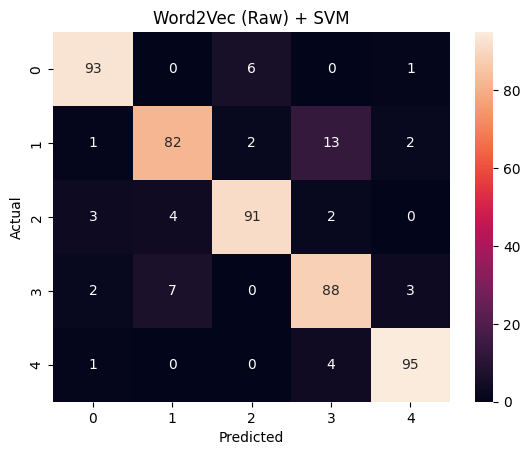

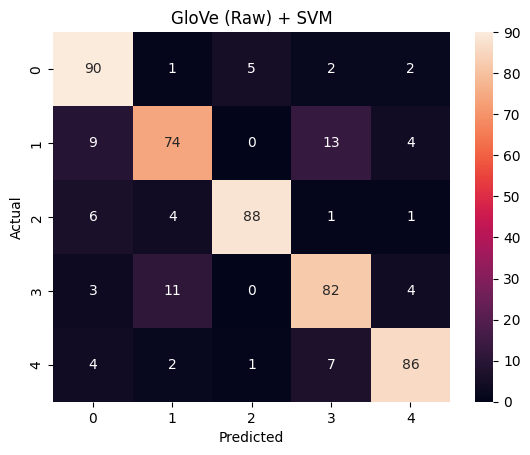

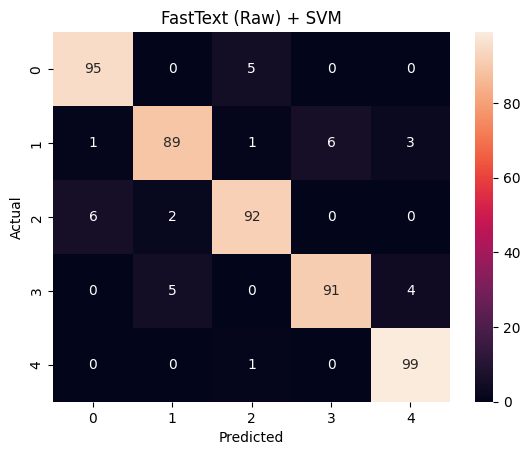

<Figure size 640x480 with 0 Axes>

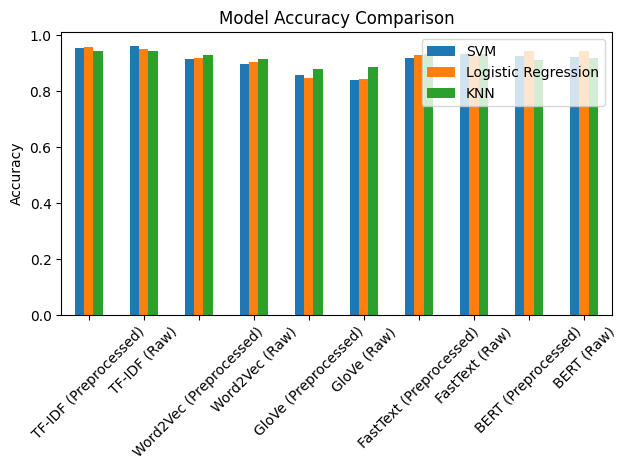


EMBEDDING MODEL INSIGHTS SUMMARY

Word2Vec:
- Loses keyword importance due to averaging embeddings
- Struggles with multi-intent sentences
- Worse than TF-IDF, better than GloVe

GloVe:
- Worst performance among embeddings
- Static vectors, not domain-specific
- Poor handling of support-ticket vocabulary

FastText:
- Best among embedding models
- Handles typos and word variations using subwords
- Still slightly worse than TF-IDF due to lack of keyword weighting

Comparison:
- TF-IDF: Best for keyword-driven tasks
- BERT: Best for context understanding
- FastText: Best among embeddings



In [32]:
# ==================== MISCLASSIFICATION + COMPARATIVE ANALYSIS ====================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# -------------------- GENERIC ANALYSIS FUNCTION --------------------
def analyze_model(feature_name, clf_name='SVM', top_k=3):
    y_pred = predictions_store[feature_name][clf_name]

    misclassified = []
    for i, idx in enumerate(x_test):
        if y_pred[i] != y_test[i]:
            misclassified.append((i, idx, y_test[i], y_pred[i]))

    print("\n" + "="*80)
    print(f"{feature_name} + {clf_name}")
    print("="*80)
    print(f"Total errors: {len(misclassified)}\n")

    for i, idx, true_label, pred_label in misclassified[:top_k]:
        print("TEXT:", df.iloc[idx]['raw_text'])
        print("TRUE:", true_label)
        print("PRED:", pred_label)
        print("-"*80)

    return misclassified


# -------------------- MODEL COMPARISON FUNCTION --------------------
def compare_models(feature1, feature2, clf='SVM', top_k=3):
    pred1 = predictions_store[feature1][clf]
    pred2 = predictions_store[feature2][clf]

    print("\n" + "="*80)
    print(f"{feature1} fails but {feature2} succeeds")
    print("="*80)

    count = 0
    for i, idx in enumerate(x_test):
        if pred1[i] != y_test[i] and pred2[i] == y_test[i]:
            print("TEXT:", df.iloc[idx]['raw_text'])
            print("TRUE:", y_test[i])
            print(f"{feature1}:", pred1[i])
            print(f"{feature2}:", pred2[i])
            print("-"*80)
            count += 1
            if count >= top_k:
                break


# ==================== ANALYZE EMBEDDING MODELS ====================

# Word2Vec
w2v_errors = analyze_model('Word2Vec (Raw)', 'SVM')
compare_models('Word2Vec (Raw)', 'TF-IDF (Raw)')
compare_models('Word2Vec (Raw)', 'BERT (Raw)')

# GloVe
glove_errors = analyze_model('GloVe (Raw)', 'SVM')
compare_models('GloVe (Raw)', 'TF-IDF (Raw)')
compare_models('GloVe (Raw)', 'BERT (Raw)')

# FastText
fasttext_errors = analyze_model('FastText (Raw)', 'SVM')
compare_models('FastText (Raw)', 'TF-IDF (Raw)')
compare_models('FastText (Raw)', 'BERT (Raw)')


# ==================== CONFUSION MATRIX VISUALIZATION ====================

def plot_conf_matrix(feature_name, clf_name='SVM'):
    y_pred = predictions_store[feature_name][clf_name]
    cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{feature_name} + {clf_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


plot_conf_matrix('Word2Vec (Raw)')
plot_conf_matrix('GloVe (Raw)')
plot_conf_matrix('FastText (Raw)')


# ==================== ACCURACY COMPARISON PLOT ====================

def plot_model_comparison(results_df):
    plt.figure()
    results_df.plot(kind='bar')
    plt.title("Model Accuracy Comparison")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_model_comparison(results_df)


# ==================== OPTIONAL: PRINT SUMMARY ====================

print("\n" + "="*80)
print("EMBEDDING MODEL INSIGHTS SUMMARY")
print("="*80)

print("""
Word2Vec:
- Loses keyword importance due to averaging embeddings
- Struggles with multi-intent sentences
- Worse than TF-IDF, better than GloVe

GloVe:
- Worst performance among embeddings
- Static vectors, not domain-specific
- Poor handling of support-ticket vocabulary

FastText:
- Best among embedding models
- Handles typos and word variations using subwords
- Still slightly worse than TF-IDF due to lack of keyword weighting

Comparison:
- TF-IDF: Best for keyword-driven tasks
- BERT: Best for context understanding
- FastText: Best among embeddings
""")

In [26]:
# ==================== RESULTS ANALYSIS ====================

results_df = pd.DataFrame(results).T[['SVM', 'Logistic Regression', 'KNN']]
macro_f1_df = pd.DataFrame(macro_f1_results).T[['SVM', 'Logistic Regression', 'KNN']]
weighted_f1_df = pd.DataFrame(weighted_f1_results).T[['SVM', 'Logistic Regression', 'KNN']]

# Combined objective prioritizes accuracy while accounting for class balance.
combined_score_df = 0.6 * results_df + 0.4 * macro_f1_df

print("\n" + "=" * 90)
print("COMPREHENSIVE CLASSIFICATION RESULTS")
print("=" * 90)
print("\nAccuracy Table:")
print(results_df.round(4).to_string())
print("\nMacro-F1 Table:")
print(macro_f1_df.round(4).to_string())
print("=" * 90)

print("\nBEST MODELS BY CLASSIFIER (Combined Score = 0.6*Acc + 0.4*Macro-F1):")
for clf_name in ['SVM', 'Logistic Regression', 'KNN']:
    best_feature = combined_score_df[clf_name].idxmax()
    best_combined = combined_score_df[clf_name].max()
    best_accuracy = results_df.loc[best_feature, clf_name]
    best_macro_f1 = macro_f1_df.loc[best_feature, clf_name]
    print(
        f"  {clf_name:<20}: {best_feature:<35} "
        f"(Acc={best_accuracy:.4f}, Macro-F1={best_macro_f1:.4f}, Combined={best_combined:.4f})"
    )

print("\nBEST OVERALL:")
best_combo = np.argmax(combined_score_df.values)
best_idx = np.unravel_index(best_combo, combined_score_df.shape)
best_feature = combined_score_df.index[best_idx[0]]
best_clf = combined_score_df.columns[best_idx[1]]
best_combined = combined_score_df.values.flatten()[best_combo]
best_acc = results_df.loc[best_feature, best_clf]
best_macro = macro_f1_df.loc[best_feature, best_clf]
print(f"  {best_feature} + {best_clf}: Acc={best_acc:.4f}, Macro-F1={best_macro:.4f}, Combined={best_combined:.4f}")


COMPREHENSIVE CLASSIFICATION RESULTS

Accuracy Table:
                           SVM  Logistic Regression    KNN
TF-IDF (Preprocessed)    0.954                0.956  0.944
TF-IDF (Raw)             0.962                0.950  0.942
Word2Vec (Preprocessed)  0.916                0.920  0.930
Word2Vec (Raw)           0.898                0.904  0.914
GloVe (Preprocessed)     0.856                0.848  0.878
GloVe (Raw)              0.840                0.842  0.886
FastText (Preprocessed)  0.918                0.930  0.932
FastText (Raw)           0.932                0.924  0.932
BERT (Preprocessed)      0.926                0.942  0.912
BERT (Raw)               0.922                0.942  0.920

Macro-F1 Table:
                            SVM  Logistic Regression     KNN
TF-IDF (Preprocessed)    0.9540               0.9560  0.9438
TF-IDF (Raw)             0.9620               0.9500  0.9418
Word2Vec (Preprocessed)  0.9160               0.9199  0.9298
Word2Vec (Raw)           0.8980    

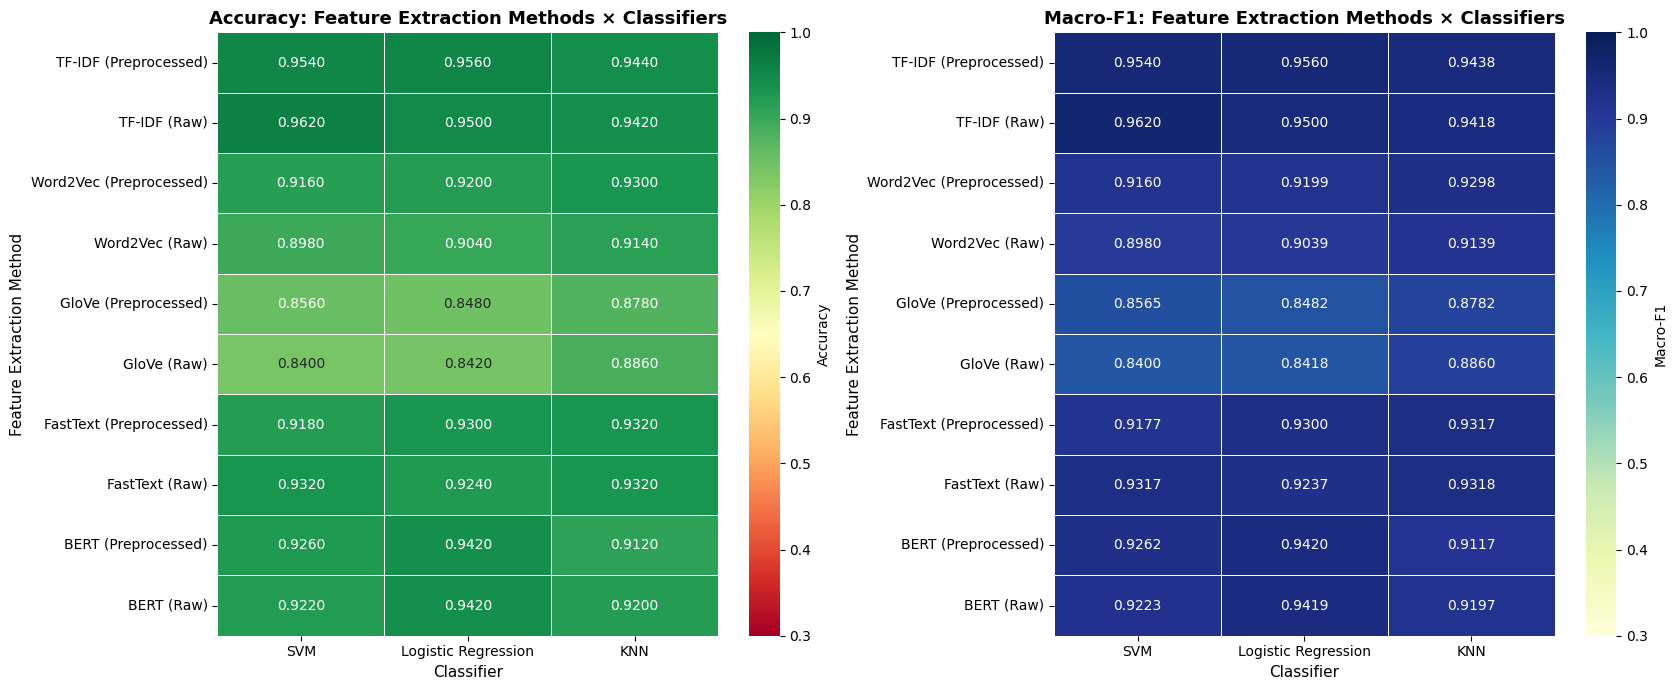

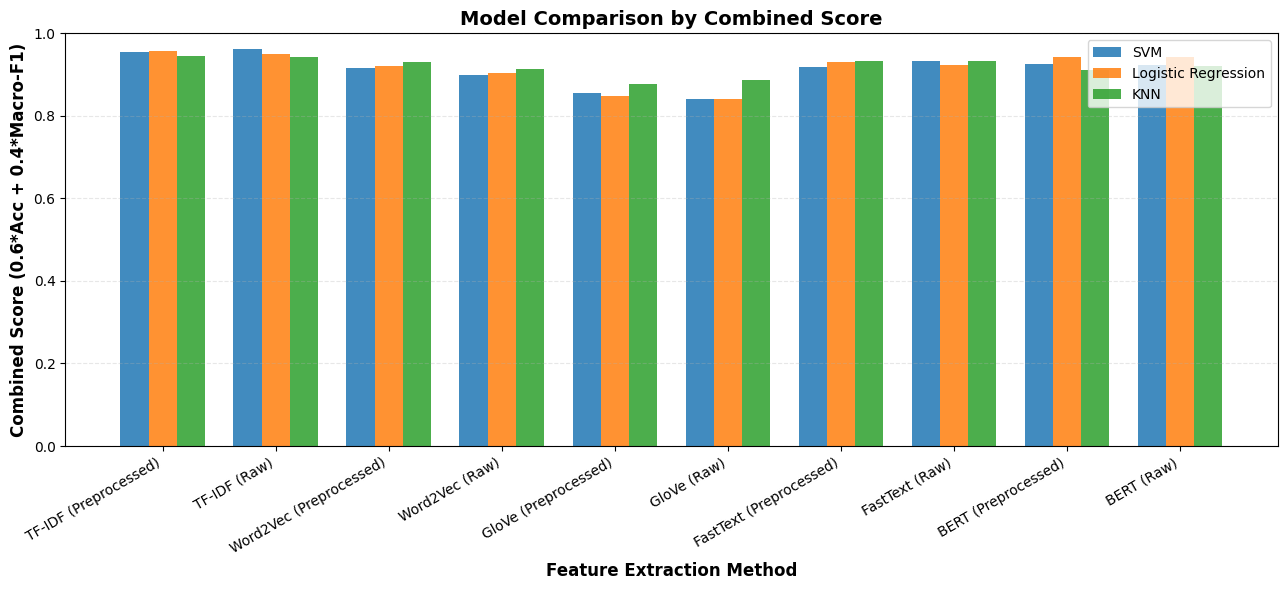

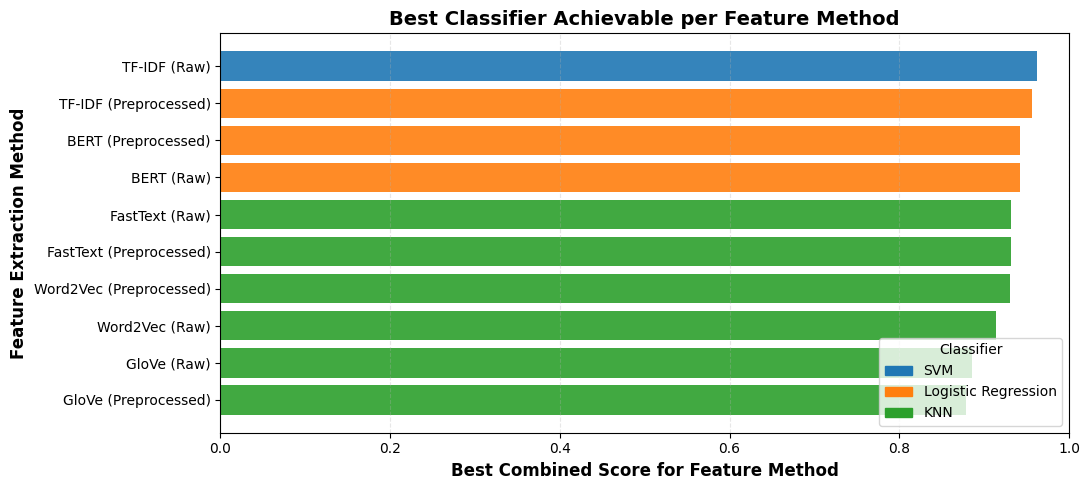

In [27]:
# ==================== VISUALIZATIONS ====================

# 1. Heatmaps for accuracy and macro-F1
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
sns.heatmap(
    results_df,
    annot=True,
    fmt='.4f',
    cmap='RdYlGn',
    cbar_kws={'label': 'Accuracy'},
    vmin=0.3,
    vmax=1.0,
    ax=axes[0],
    linewidths=0.5,
 )
axes[0].set_title('Accuracy: Feature Extraction Methods × Classifiers', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Classifier', fontsize=11)
axes[0].set_ylabel('Feature Extraction Method', fontsize=11)

sns.heatmap(
    macro_f1_df,
    annot=True,
    fmt='.4f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Macro-F1'},
    vmin=0.3,
    vmax=1.0,
    ax=axes[1],
    linewidths=0.5,
 )
axes[1].set_title('Macro-F1: Feature Extraction Methods × Classifiers', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Classifier', fontsize=11)
axes[1].set_ylabel('Feature Extraction Method', fontsize=11)
plt.tight_layout()
plt.show()

# 2. Bar plot for combined score
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(combined_score_df.index))
width = 0.25

for i, clf_name in enumerate(['SVM', 'Logistic Regression', 'KNN']):
    ax.bar(x + i * width, combined_score_df[clf_name], width, label=clf_name, alpha=0.85)

ax.set_xlabel('Feature Extraction Method', fontsize=12, fontweight='bold')
ax.set_ylabel('Combined Score (0.6*Acc + 0.4*Macro-F1)', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison by Combined Score', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(combined_score_df.index, rotation=30, ha='right')
ax.legend()
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# 3. Best classifier by feature method
best_classifier_for_feature = combined_score_df.idxmax(axis=1)
best_combined_for_feature = combined_score_df.max(axis=1).sort_values(ascending=True)

palette = {
    'SVM': '#1f77b4',
    'Logistic Regression': '#ff7f0e',
    'KNN': '#2ca02c',
}
bar_colors = [palette[best_classifier_for_feature[idx]] for idx in best_combined_for_feature.index]

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(best_combined_for_feature.index, best_combined_for_feature.values, color=bar_colors, alpha=0.9)
ax.set_xlabel('Best Combined Score for Feature Method', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature Extraction Method', fontsize=12, fontweight='bold')
ax.set_title('Best Classifier Achievable per Feature Method', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_xlim([0.0, 1.0])

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=palette[name])
    for name in ['SVM', 'Logistic Regression', 'KNN']
 ]
ax.legend(legend_handles, ['SVM', 'Logistic Regression', 'KNN'], title='Classifier', loc='lower right')
plt.tight_layout()
plt.show()

In [28]:
# ==================== DETAILED ANALYSIS: BEST MODELS ====================

print("\n" + "=" * 90)
print("DETAILED METRICS FOR TOP 5 MODELS (RANKED BY COMBINED SCORE)")
print("=" * 90)

all_accuracies = []
for feature_name in combined_score_df.index:
    for clf_name in combined_score_df.columns:
        combined = combined_score_df.loc[feature_name, clf_name]
        accuracy = results_df.loc[feature_name, clf_name]
        macro_f1 = macro_f1_df.loc[feature_name, clf_name]
        all_accuracies.append((combined, accuracy, macro_f1, feature_name, clf_name))

all_accuracies.sort(reverse=True)

for rank, (combined, accuracy, macro_f1, feature_name, clf_name) in enumerate(all_accuracies[:5], 1):
    print(
        f"\n{rank}. {feature_name} + {clf_name}: "
        f"Acc={accuracy:.4f}, Macro-F1={macro_f1:.4f}, Combined={combined:.4f}"
    )
    print("-" * 90)

    X_train, X_test = features[feature_name]
    model = build_classifier(clf_name)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        labels=unique_labels,
        average=None,
        zero_division=0,
    )

    print(f"{'Class':<25} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
    print("-" * 90)
    for i, label in enumerate(unique_labels):
        print(f"{label:<25} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f}")


DETAILED METRICS FOR TOP 5 MODELS (RANKED BY COMBINED SCORE)

1. TF-IDF (Raw) + SVM: Acc=0.9620, Macro-F1=0.9620, Combined=0.9620
------------------------------------------------------------------------------------------
Class                     Precision    Recall       F1-Score    
------------------------------------------------------------------------------------------
account_access            0.9800       0.9800       0.9800      
billing                   0.9327       0.9700       0.9510      
bug_report                0.9796       0.9600       0.9697      
refund_request            0.9684       0.9200       0.9436      
shipping_delivery         0.9515       0.9800       0.9655      

2. TF-IDF (Preprocessed) + Logistic Regression: Acc=0.9560, Macro-F1=0.9560, Combined=0.9560
------------------------------------------------------------------------------------------
Class                     Precision    Recall       F1-Score    
-----------------------------------------------

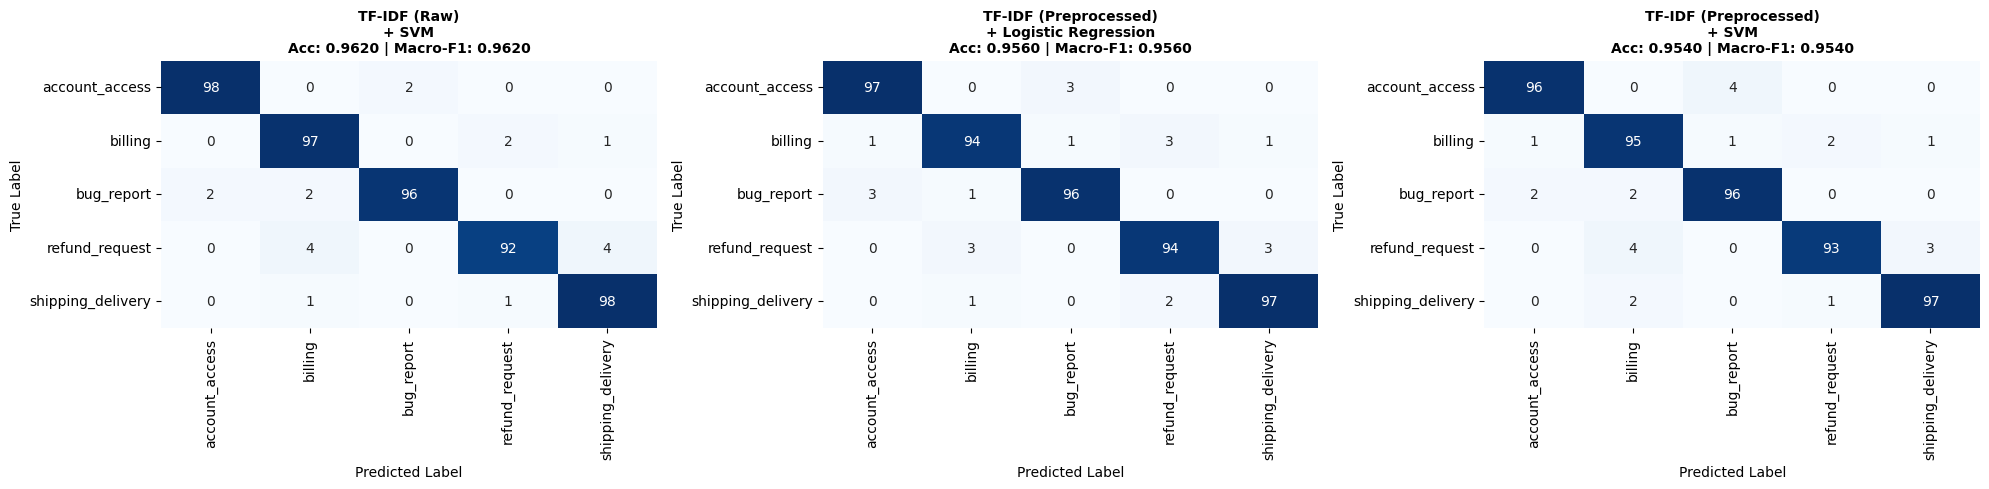

In [29]:
# ==================== CONFUSION MATRICES FOR TOP MODELS ====================

# Get top 3 models for confusion matrix visualization
top_3 = all_accuracies[:3]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for idx, (combined, accuracy, macro_f1, feature_name, clf_name) in enumerate(top_3):
    X_train, X_test = features[feature_name]
    model = build_classifier(clf_name)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred, labels=unique_labels)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[idx],
        xticklabels=unique_labels,
        yticklabels=unique_labels,
        cbar=False
    )
    axes[idx].set_title(
        f'{feature_name}\n+ {clf_name}\nAcc: {accuracy:.4f} | Macro-F1: {macro_f1:.4f}',
        fontsize=10,
        fontweight='bold'
    )
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

In [30]:
# ==================== SUMMARY INSIGHTS ====================

print("\n" + "=" * 90)
print("KEY INSIGHTS")
print("=" * 90)

# 1. Best feature per classifier
print("\n1. BEST FEATURE METHOD PER CLASSIFIER:")
print("-" * 90)
for clf_name in ['SVM', 'Logistic Regression', 'KNN']:
    best_feature = combined_score_df[clf_name].idxmax()
    best_score = combined_score_df.loc[best_feature, clf_name]
    best_acc = results_df.loc[best_feature, clf_name]
    best_macro = macro_f1_df.loc[best_feature, clf_name]
    print(
        f"{clf_name:<20}: {best_feature:<28} | Acc={best_acc:.4f} | Macro-F1={best_macro:.4f} | Combined={best_score:.4f}"
    )

# 2. Best classifier summary
print("\n\n2. CLASSIFIER AVERAGES:")
print("-" * 90)
for clf_name in ['SVM', 'Logistic Regression', 'KNN']:
    avg_acc = results_df[clf_name].mean()
    avg_macro = macro_f1_df[clf_name].mean()
    avg_combined = combined_score_df[clf_name].mean()
    print(
        f"{clf_name:<20}: Acc={avg_acc:.4f} | Macro-F1={avg_macro:.4f} | Combined={avg_combined:.4f}"
    )

# 3. Feature extraction ranking by combined score
print("\n\n3. FEATURE METHOD RANKING (Average Combined Score):")
print("-" * 90)
feature_avg = combined_score_df.mean(axis=1).sort_values(ascending=False)
for i, (feature, avg) in enumerate(feature_avg.items(), 1):
    print(f"{i:2d}. {feature:<35}: {avg:.4f}")

best_overall_score = combined_score_df.values.max()
best_flat_idx = np.argmax(combined_score_df.values)
best_row, best_col = np.unravel_index(best_flat_idx, combined_score_df.shape)
best_overall_feature = combined_score_df.index[best_row]
best_overall_classifier = combined_score_df.columns[best_col]

print("\n\n4. PRODUCTION CANDIDATE:")
print("-" * 90)
print(
    f"Use {best_overall_feature} + {best_overall_classifier} first "
    f"(combined={best_overall_score:.4f})."
 )

print("\n" + "=" * 90)


KEY INSIGHTS

1. BEST FEATURE METHOD PER CLASSIFIER:
------------------------------------------------------------------------------------------
SVM                 : TF-IDF (Raw)                 | Acc=0.9620 | Macro-F1=0.9620 | Combined=0.9620
Logistic Regression : TF-IDF (Preprocessed)        | Acc=0.9560 | Macro-F1=0.9560 | Combined=0.9560
KNN                 : TF-IDF (Preprocessed)        | Acc=0.9440 | Macro-F1=0.9438 | Combined=0.9439


2. CLASSIFIER AVERAGES:
------------------------------------------------------------------------------------------
SVM                 : Acc=0.9124 | Macro-F1=0.9124 | Combined=0.9124
Logistic Regression : Acc=0.9158 | Macro-F1=0.9157 | Combined=0.9158
KNN                 : Acc=0.9190 | Macro-F1=0.9188 | Combined=0.9189


3. FEATURE METHOD RANKING (Average Combined Score):
------------------------------------------------------------------------------------------
 1. TF-IDF (Preprocessed)              : 0.9513
 2. TF-IDF (Raw)                      